# inzva DLSG #10 - Homework 2: GNN Graph Classification

**Objective**: Compare Feature-Only models vs Message Passing GNNs for graph classification.

**Models**:
- Feature-Only: `LinearBaseline`, `MLPBaseline`, `DeepSets`
- Message Passing: `GCN`, `GraphSAGE`, `GAT`, `GIN`

**Datasets**: `PROTEINS`, `IMDB-MULTI`, `REDDIT-BINARY`, `ogbg-molhiv`

**Setup**: hidden=64, layers=4, dropout=0.5, lr=0.001, BS=64, 100 epochs, early stopping (patience=20), 3 seeds (0,1,2)

## 1. Setup & Installation

In [1]:
# 1. Mevcut karışıklığı temizle
!pip uninstall torch torchvision torchaudio -y
!pip uninstall torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric -y

# 2. Stabil PyTorch ve CUDA uyumlu sürümü kur (Hızlıdır)
!pip install torch==2.1.0  --index-url https://download.pytorch.org/whl/cu121 -q

# 3. Hazır binary dosyaları kullanarak Graf kütüphanelerini kur
!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv -f https://data.pyg.org/whl/torch-2.1.0+cu121.html -q
!pip install torch-geometric ogb -q

# 4. Kontrol Et
import torch
import torch_geometric
print(f"Sistem Hazır! \nPyTorch: {torch.__version__} \nPyG: {torch_geometric.__version__}")

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
ERROR: Could not find a version that satisfies the requirement torch==2.1.0 (from versions: 2.2.0+cu121, 2.2.1+cu121, 2.2.2+cu121, 2.3.0+cu121, 2.3.1+cu121, 2.4.0+cu121, 2.4.1+cu121, 2.5.0+cu121, 2.5.1+cu121)
ERROR: No matching distribution found for torch==2.1.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 4.6 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparin

In [2]:
import os
import json
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.datasets import TUDataset
from torch_geometric.loader import DataLoader
from torch_geometric.transforms import BaseTransform
from torch_geometric.nn import (
    GCNConv, SAGEConv, GATConv, GINConv,
    global_mean_pool, global_add_pool, global_max_pool
)
from ogb.graphproppred import PygGraphPropPredDataset
from sklearn.metrics import roc_auc_score, accuracy_score
from tqdm.auto import tqdm

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
Using device: cuda


## 2. Utility Functions

In [3]:
def set_seed(seed):
    """Set random seed for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def count_parameters(model):
    """Count trainable parameters."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


class EarlyStopping:
    """Early stopping based on validation metric."""
    def __init__(self, patience=20, mode='max'):
        self.patience = patience
        self.mode = mode
        self.counter = 0
        self.best_score = None
        self.best_epoch = 0
        self.early_stop = False

    def __call__(self, score, epoch):
        if self.best_score is None:
            self.best_score = score
            self.best_epoch = epoch
            return False
        improved = (score > self.best_score) if self.mode == 'max' else (score < self.best_score)
        if improved:
            self.best_score = score
            self.best_epoch = epoch
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
                return True
        return False

## 3. Data Loading

In [9]:
class AddDegreeFeature(BaseTransform):
    """Add node degree as one-hot feature for graphs without node features."""
    def forward(self, data):  # Renamed __call__ to forward
        if data.x is None:
            deg = torch.zeros(data.num_nodes, dtype=torch.long)
            row, col = data.edge_index
            for node in range(data.num_nodes):
                deg[node] = (row == node).sum()
            max_degree = 100
            deg = deg.clamp(max=max_degree)
            data.x = torch.zeros(data.num_nodes, max_degree + 1)
            data.x.scatter_(1, deg.unsqueeze(1), 1.0)
        elif data.x.dtype == torch.long:
            data.x = data.x.float()
        return data

## 4. Model Definitions

In [5]:
def get_pooling(pool_type):
    pools = {'mean': global_mean_pool, 'sum': global_add_pool, 'max': global_max_pool}
    return pools[pool_type]

# ─── Feature-Only Models ─────────────────────────────────────────

class LinearBaseline(nn.Module):
    """Global pool -> Linear. No hidden layers, no message passing."""
    def __init__(self, num_features, num_classes, hidden_dim=64, num_layers=4,
                 dropout=0.5, pool='mean', **kw):
        super().__init__()
        self.pool = get_pooling(pool)
        self.classifier = nn.Linear(num_features, num_classes)

    def forward(self, x, edge_index, batch):
        x = self.pool(x, batch)
        return self.classifier(x)


class MLPBaseline(nn.Module):
    """Global pool -> MLP. Hidden layers but no message passing."""
    def __init__(self, num_features, num_classes, hidden_dim=64, num_layers=4,
                 dropout=0.5, pool='mean', **kw):
        super().__init__()
        self.pool = get_pooling(pool)
        layers = []
        in_d = num_features
        for _ in range(num_layers - 1):
            layers += [nn.Linear(in_d, hidden_dim), nn.BatchNorm1d(hidden_dim),
                       nn.ReLU(), nn.Dropout(dropout)]
            in_d = hidden_dim
        self.mlp = nn.Sequential(*layers)
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, edge_index, batch):
        x = self.pool(x, batch)
        return self.classifier(self.mlp(x))


class DeepSets(nn.Module):
    """Per-node MLP -> Global pool -> Classifier MLP. Permutation invariant."""
    def __init__(self, num_features, num_classes, hidden_dim=64, num_layers=4,
                 dropout=0.5, pool='mean', **kw):
        super().__init__()
        self.pool = get_pooling(pool)
        enc = []
        in_d = num_features
        for _ in range(num_layers // 2):
            enc += [nn.Linear(in_d, hidden_dim), nn.BatchNorm1d(hidden_dim),
                    nn.ReLU(), nn.Dropout(dropout)]
            in_d = hidden_dim
        self.encoder = nn.Sequential(*enc)
        dec = []
        for _ in range(num_layers - num_layers // 2 - 1):
            dec += [nn.Linear(hidden_dim, hidden_dim), nn.BatchNorm1d(hidden_dim),
                    nn.ReLU(), nn.Dropout(dropout)]
        self.decoder = nn.Sequential(*dec)
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, edge_index, batch):
        x = self.encoder(x)
        x = self.pool(x, batch)
        x = self.decoder(x)
        return self.classifier(x)


# ─── Message Passing Models ──────────────────────────────────────

class GCN(nn.Module):
    def __init__(self, num_features, num_classes, hidden_dim=64, num_layers=4,
                 dropout=0.5, pool='mean', **kw):
        super().__init__()
        self.pool = get_pooling(pool)
        self.dropout = dropout
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()
        self.convs.append(GCNConv(num_features, hidden_dim))
        self.bns.append(nn.BatchNorm1d(hidden_dim))
        for _ in range(num_layers - 1):
            self.convs.append(GCNConv(hidden_dim, hidden_dim))
            self.bns.append(nn.BatchNorm1d(hidden_dim))
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, edge_index, batch):
        for conv, bn in zip(self.convs, self.bns):
            x = F.dropout(F.relu(bn(conv(x, edge_index))), self.dropout, self.training)
        return self.classifier(self.pool(x, batch))


class GraphSAGE(nn.Module):
    def __init__(self, num_features, num_classes, hidden_dim=64, num_layers=4,
                 dropout=0.5, pool='mean', **kw):
        super().__init__()
        self.pool = get_pooling(pool)
        self.dropout = dropout
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()
        self.convs.append(SAGEConv(num_features, hidden_dim))
        self.bns.append(nn.BatchNorm1d(hidden_dim))
        for _ in range(num_layers - 1):
            self.convs.append(SAGEConv(hidden_dim, hidden_dim))
            self.bns.append(nn.BatchNorm1d(hidden_dim))
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, edge_index, batch):
        for conv, bn in zip(self.convs, self.bns):
            x = F.dropout(F.relu(bn(conv(x, edge_index))), self.dropout, self.training)
        return self.classifier(self.pool(x, batch))


class GAT(nn.Module):
    def __init__(self, num_features, num_classes, hidden_dim=64, num_layers=4,
                 dropout=0.5, pool='mean', heads=4, **kw):
        super().__init__()
        self.pool = get_pooling(pool)
        self.dropout = dropout
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()
        self.convs.append(GATConv(num_features, hidden_dim // heads, heads=heads, dropout=dropout))
        self.bns.append(nn.BatchNorm1d(hidden_dim))
        for _ in range(num_layers - 2):
            self.convs.append(GATConv(hidden_dim, hidden_dim // heads, heads=heads, dropout=dropout))
            self.bns.append(nn.BatchNorm1d(hidden_dim))
        self.convs.append(GATConv(hidden_dim, hidden_dim, heads=1, concat=False, dropout=dropout))
        self.bns.append(nn.BatchNorm1d(hidden_dim))
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, edge_index, batch):
        for conv, bn in zip(self.convs, self.bns):
            x = F.dropout(F.relu(bn(conv(x, edge_index))), self.dropout, self.training)
        return self.classifier(self.pool(x, batch))


class GIN(nn.Module):
    def __init__(self, num_features, num_classes, hidden_dim=64, num_layers=4,
                 dropout=0.5, pool='mean', **kw):
        super().__init__()
        self.pool = get_pooling(pool)
        self.dropout = dropout
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()
        mlp = nn.Sequential(nn.Linear(num_features, hidden_dim), nn.BatchNorm1d(hidden_dim),
                            nn.ReLU(), nn.Linear(hidden_dim, hidden_dim))
        self.convs.append(GINConv(mlp))
        self.bns.append(nn.BatchNorm1d(hidden_dim))
        for _ in range(num_layers - 1):
            mlp = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.BatchNorm1d(hidden_dim),
                                nn.ReLU(), nn.Linear(hidden_dim, hidden_dim))
            self.convs.append(GINConv(mlp))
            self.bns.append(nn.BatchNorm1d(hidden_dim))
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, edge_index, batch):
        for conv, bn in zip(self.convs, self.bns):
            x = F.dropout(F.relu(bn(conv(x, edge_index))), self.dropout, self.training)
        return self.classifier(self.pool(x, batch))


MODEL_REGISTRY = {
    'linear': LinearBaseline, 'mlp': MLPBaseline, 'deepsets': DeepSets,
    'gcn': GCN, 'graphsage': GraphSAGE, 'gat': GAT, 'gin': GIN,
}

def get_model(name, **kwargs):
    return MODEL_REGISTRY[name](**kwargs)

## 5. Training & Evaluation

In [6]:
def train_epoch(model, loader, optimizer, device, task_type):
    model.train()
    total_loss, n = 0, 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.batch)
        if task_type == 'binary':
            target = data.y.float().view(-1)
            valid = ~torch.isnan(target)
            if valid.sum() == 0: continue
            loss = F.binary_cross_entropy_with_logits(out[valid, 1], target[valid])
        else:
            loss = F.cross_entropy(out, data.y.long().view(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        n += 1
    return total_loss / max(n, 1)


@torch.no_grad()
def evaluate(model, loader, device, task_type, metric):
    model.eval()
    total_loss, n = 0, 0
    all_preds, all_labels, all_probs = [], [], []
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index, data.batch)
        if task_type == 'binary':
            target = data.y.float().view(-1)
            valid = ~torch.isnan(target)
            if valid.sum() == 0: continue
            loss = F.binary_cross_entropy_with_logits(out[valid, 1], target[valid])
            all_probs.append(torch.sigmoid(out[valid, 1]).cpu().numpy())
            all_labels.append(target[valid].cpu().numpy())
        else:
            target = data.y.long().view(-1)
            loss = F.cross_entropy(out, target)
            all_preds.append(out.argmax(1).cpu().numpy())
            all_labels.append(target.cpu().numpy())
        total_loss += loss.item()
        n += 1
    avg_loss = total_loss / max(n, 1)
    all_labels = np.concatenate(all_labels)
    if metric == 'rocauc':
        all_probs = np.concatenate(all_probs)
        try: score = roc_auc_score(all_labels, all_probs)
        except: score = 0.0
    else:
        all_preds = np.concatenate(all_preds)
        score = accuracy_score(all_labels, all_preds)
    return avg_loss, score


def train_and_evaluate(model, train_loader, val_loader, test_loader,
                       device, task_type, metric,
                       epochs=100, lr=0.001, patience=20, seed=0, verbose=True):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    es = EarlyStopping(patience=patience, mode='max')
    history = defaultdict(list)
    best_val, best_state = 0.0, None
    t0 = time.time()
    m_name = 'ROC-AUC' if metric == 'rocauc' else 'Accuracy'

    for epoch in range(1, epochs + 1):
        tr_loss = train_epoch(model, train_loader, optimizer, device, task_type)
        v_loss, v_metric = evaluate(model, val_loader, device, task_type, metric)
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(v_loss)
        history['val_metric'].append(v_metric)
        history['epoch'].append(epoch)
        if v_metric > best_val:
            best_val = v_metric
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        if verbose and (epoch % 10 == 0 or epoch == 1):
            print(f'  Epoch {epoch:3d} | tr_loss {tr_loss:.4f} | val_loss {v_loss:.4f} | '
                  f'val_{metric} {v_metric:.4f} | {time.time()-t0:.1f}s')
        if es(v_metric, epoch):
            if verbose: print(f'  Early stop at epoch {epoch}.')
            break

    if best_state: model.load_state_dict(best_state)
    _, test_metric = evaluate(model, test_loader, device, task_type, metric)
    if verbose:
        print(f'  Best val {m_name}: {best_val:.4f} (epoch {es.best_epoch})')
        print(f'  Test {m_name}: {test_metric:.4f}')
    return best_val, test_metric, dict(history)

## 6. Experiment Runner

In [7]:
def run_experiment(dataset_name, model_name, pool='mean', hidden=64, layers=4,
                   dropout=0.5, lr=0.001, batch_size=64, epochs=100,
                   patience=20, seeds=[0, 1, 2], save_plots=True):
    """Run a single experiment configuration across multiple seeds."""
    print(f'\n{"="*60}')
    print(f'  Dataset: {dataset_name} | Model: {model_name.upper()} | Pool: {pool}')
    print(f'  Hidden: {hidden} | Layers: {layers} | Dropout: {dropout}')
    print(f'  LR: {lr} | BS: {batch_size} | Seeds: {seeds}')
    print(f'{"="*60}')

    dataset, num_features, num_classes, task_type, metric = get_dataset(dataset_name)
    val_metrics, test_metrics, all_histories = [], [], []

    for seed in seeds:
        set_seed(seed)
        train_loader, val_loader, test_loader = get_data_loaders(
            dataset, dataset_name, batch_size, seed)
        if seed == seeds[0]:
            print_dataset_info(dataset_name, dataset, train_loader, val_loader, test_loader)

        model = get_model(model_name, num_features=num_features, num_classes=num_classes,
                          hidden_dim=hidden, num_layers=layers, dropout=dropout, pool=pool).to(DEVICE)
        params = count_parameters(model)
        print(f'\n  Model: {model_name.upper()} | Params: {params:,} | Seed: {seed} | Device: {DEVICE}')

        best_val, test_m, history = train_and_evaluate(
            model, train_loader, val_loader, test_loader,
            DEVICE, task_type, metric, epochs, lr, patience, seed)
        val_metrics.append(best_val)
        test_metrics.append(test_m)
        all_histories.append(history)

    # Summary
    m_name = 'ROC-AUC' if metric == 'rocauc' else 'Accuracy'
    print(f'\n{"="*60}')
    print(f'  RESULTS: {dataset_name} | {model_name.upper()}')
    print(f'  Val  {m_name}: {np.mean(val_metrics):.4f} ± {np.std(val_metrics):.4f}')
    print(f'  Test {m_name}: {np.mean(test_metrics):.4f} ± {np.std(test_metrics):.4f}')
    print(f'{"="*60}')

    # Plot training curves
    if save_plots:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        colors = ['tab:blue', 'tab:orange', 'tab:green']
        for i, (h, s) in enumerate(zip(all_histories, seeds)):
            axes[0].plot(h['epoch'], h['train_loss'], '--', color=colors[i], alpha=0.5, label=f'Train (s={s})')
            axes[0].plot(h['epoch'], h['val_loss'], color=colors[i], label=f'Val (s={s})')
            axes[1].plot(h['epoch'], h['val_metric'], color=colors[i], label=f'Seed {s}')
        axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
        axes[0].set_title(f'{dataset_name} - {model_name.upper()} Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
        axes[1].set_xlabel('Epoch'); axes[1].set_ylabel(m_name)
        axes[1].set_title(f'{dataset_name} - {model_name.upper()} {m_name}'); axes[1].legend(); axes[1].grid(alpha=0.3)
        plt.tight_layout(); plt.show()

    return {
        'dataset': dataset_name, 'model': model_name, 'pool': pool,
        'params': params, 'metric': metric,
        'val_mean': np.mean(val_metrics), 'val_std': np.std(val_metrics),
        'test_mean': np.mean(test_metrics), 'test_std': np.std(test_metrics),
        'val_scores': val_metrics, 'test_scores': test_metrics,
    }

## 7. Part 1: Feature-Only Models (PROTEINS & REDDIT-BINARY)


  Dataset: PROTEINS | Model: LINEAR | Pool: mean
  Hidden: 64 | Layers: 4 | Dropout: 0.5
  LR: 0.001 | BS: 64 | Seeds: [0, 1, 2]


Processing...
Done!



Dataset: PROTEINS
  Graphs: 1113 | Features: 3 | Classes: 2
  Train/Val/Test: 890/111/112
  Avg nodes: 39.1 ± 45.8
  Avg edges: 145.6 ± 169.2

  Model: LINEAR | Params: 8 | Seed: 0 | Device: cuda
  Epoch   1 | tr_loss 0.6952 | val_loss 0.6968 | val_accuracy 0.4955 | 0.8s
  Epoch  10 | tr_loss 0.6754 | val_loss 0.6717 | val_accuracy 0.6216 | 2.4s
  Epoch  20 | tr_loss 0.6735 | val_loss 0.6693 | val_accuracy 0.6216 | 3.5s
  Early stop at epoch 23.
  Best val Accuracy: 0.6396 (epoch 3)
  Test Accuracy: 0.6429

  Model: LINEAR | Params: 8 | Seed: 1 | Device: cuda
  Epoch   1 | tr_loss 0.7938 | val_loss 0.7982 | val_accuracy 0.3423 | 0.1s
  Epoch  10 | tr_loss 0.7262 | val_loss 0.7297 | val_accuracy 0.4414 | 0.7s
  Epoch  20 | tr_loss 0.7015 | val_loss 0.7031 | val_accuracy 0.5676 | 2.2s
  Epoch  30 | tr_loss 0.6925 | val_loss 0.6928 | val_accuracy 0.6306 | 2.9s
  Epoch  40 | tr_loss 0.6868 | val_loss 0.6863 | val_accuracy 0.6216 | 3.6s
  Epoch  50 | tr_loss 0.6826 | val_loss 0.6812 | val_

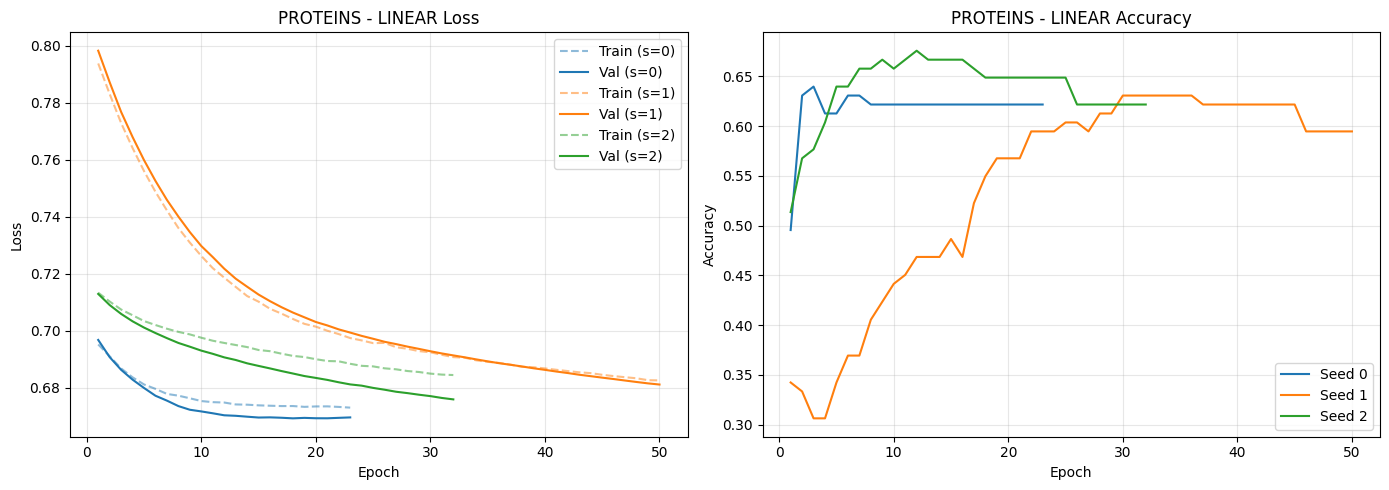


  Dataset: PROTEINS | Model: MLP | Pool: mean
  Hidden: 64 | Layers: 4 | Dropout: 0.5
  LR: 0.001 | BS: 64 | Seeds: [0, 1, 2]

Dataset: PROTEINS
  Graphs: 1113 | Features: 3 | Classes: 2
  Train/Val/Test: 890/111/112
  Avg nodes: 39.1 ± 45.8
  Avg edges: 145.6 ± 169.2

  Model: MLP | Params: 9,090 | Seed: 0 | Device: cuda
  Epoch   1 | tr_loss 0.7287 | val_loss 0.6667 | val_accuracy 0.6306 | 0.2s
  Epoch  10 | tr_loss 0.6174 | val_loss 0.5777 | val_accuracy 0.7117 | 1.5s
  Epoch  20 | tr_loss 0.6152 | val_loss 0.5664 | val_accuracy 0.7027 | 2.7s
  Early stop at epoch 24.
  Best val Accuracy: 0.7117 (epoch 4)
  Test Accuracy: 0.6429

  Model: MLP | Params: 9,090 | Seed: 1 | Device: cuda
  Epoch   1 | tr_loss 0.7348 | val_loss 0.6735 | val_accuracy 0.6486 | 0.1s
  Epoch  10 | tr_loss 0.6050 | val_loss 0.6225 | val_accuracy 0.6847 | 1.0s
  Epoch  20 | tr_loss 0.6005 | val_loss 0.6213 | val_accuracy 0.6847 | 2.0s
  Early stop at epoch 26.
  Best val Accuracy: 0.7117 (epoch 6)
  Test Accur

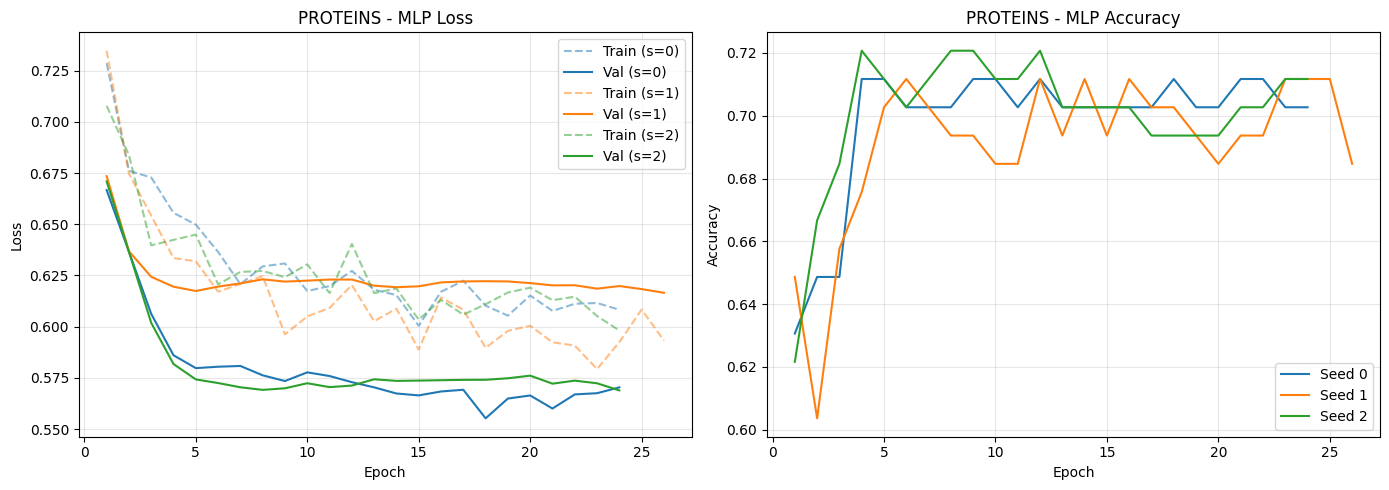


  Dataset: PROTEINS | Model: DEEPSETS | Pool: mean
  Hidden: 64 | Layers: 4 | Dropout: 0.5
  LR: 0.001 | BS: 64 | Seeds: [0, 1, 2]

Dataset: PROTEINS
  Graphs: 1113 | Features: 3 | Classes: 2
  Train/Val/Test: 890/111/112
  Avg nodes: 39.1 ± 45.8
  Avg edges: 145.6 ± 169.2

  Model: DEEPSETS | Params: 9,090 | Seed: 0 | Device: cuda
  Epoch   1 | tr_loss 0.7458 | val_loss 0.6850 | val_accuracy 0.6396 | 0.1s
  Epoch  10 | tr_loss 0.6353 | val_loss 0.5898 | val_accuracy 0.6847 | 1.1s
  Epoch  20 | tr_loss 0.6146 | val_loss 0.5711 | val_accuracy 0.6757 | 2.3s
  Epoch  30 | tr_loss 0.5977 | val_loss 0.5595 | val_accuracy 0.7477 | 3.5s
  Epoch  40 | tr_loss 0.5975 | val_loss 0.5459 | val_accuracy 0.7387 | 5.2s
  Early stop at epoch 42.
  Best val Accuracy: 0.7658 (epoch 22)
  Test Accuracy: 0.6429

  Model: DEEPSETS | Params: 9,090 | Seed: 1 | Device: cuda
  Epoch   1 | tr_loss 0.7698 | val_loss 0.6941 | val_accuracy 0.4054 | 0.2s
  Epoch  10 | tr_loss 0.6383 | val_loss 0.6208 | val_accurac

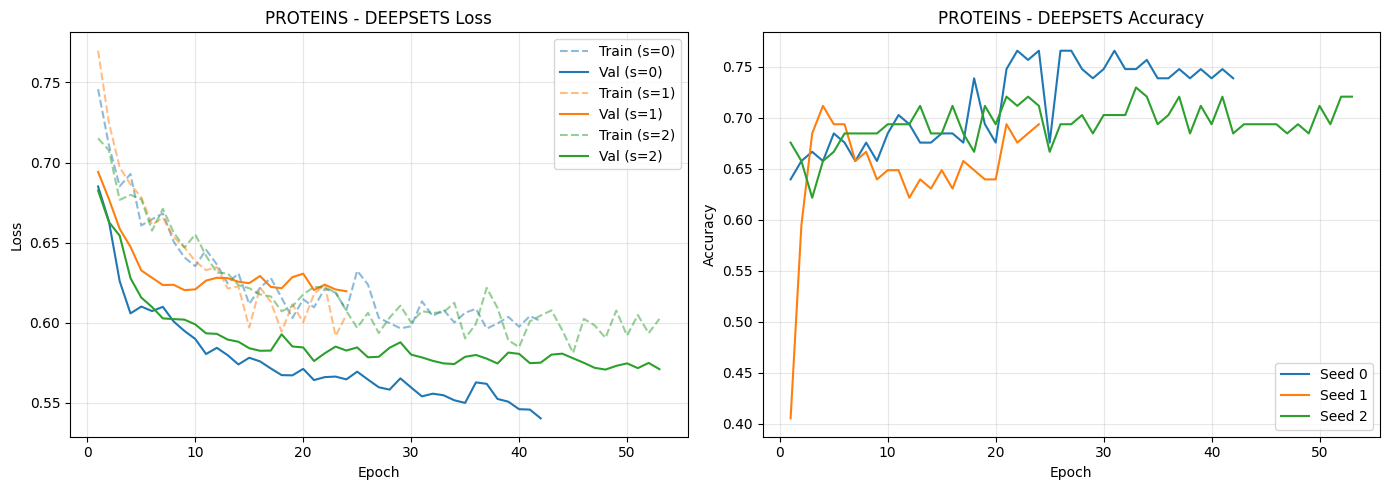


  Dataset: REDDIT-BINARY | Model: LINEAR | Pool: mean
  Hidden: 64 | Layers: 4 | Dropout: 0.5
  LR: 0.001 | BS: 64 | Seeds: [0, 1, 2]


Processing...
Done!



Dataset: REDDIT-BINARY
  Graphs: 2000 | Features: 101 | Classes: 2
  Train/Val/Test: 1600/200/200
  Avg nodes: 429.6 ± 554.1
  Avg edges: 995.5 ± 1246.0

  Model: LINEAR | Params: 204 | Seed: 0 | Device: cuda
  Epoch   1 | tr_loss 0.6944 | val_loss 0.6928 | val_accuracy 0.5100 | 14.3s
  Epoch  10 | tr_loss 0.6905 | val_loss 0.6911 | val_accuracy 0.5800 | 144.5s
  Epoch  20 | tr_loss 0.6881 | val_loss 0.6893 | val_accuracy 0.6000 | 288.5s
  Early stop at epoch 24.
  Best val Accuracy: 0.6000 (epoch 4)
  Test Accuracy: 0.5950

  Model: LINEAR | Params: 204 | Seed: 1 | Device: cuda
  Epoch   1 | tr_loss 0.6957 | val_loss 0.6940 | val_accuracy 0.5100 | 13.7s
  Epoch  10 | tr_loss 0.6913 | val_loss 0.6915 | val_accuracy 0.5900 | 137.9s
  Epoch  20 | tr_loss 0.6888 | val_loss 0.6897 | val_accuracy 0.6100 | 275.5s
  Epoch  30 | tr_loss 0.6865 | val_loss 0.6880 | val_accuracy 0.6200 | 413.0s
  Epoch  40 | tr_loss 0.6843 | val_loss 0.6864 | val_accuracy 0.6150 | 550.8s
  Early stop at epoch 42

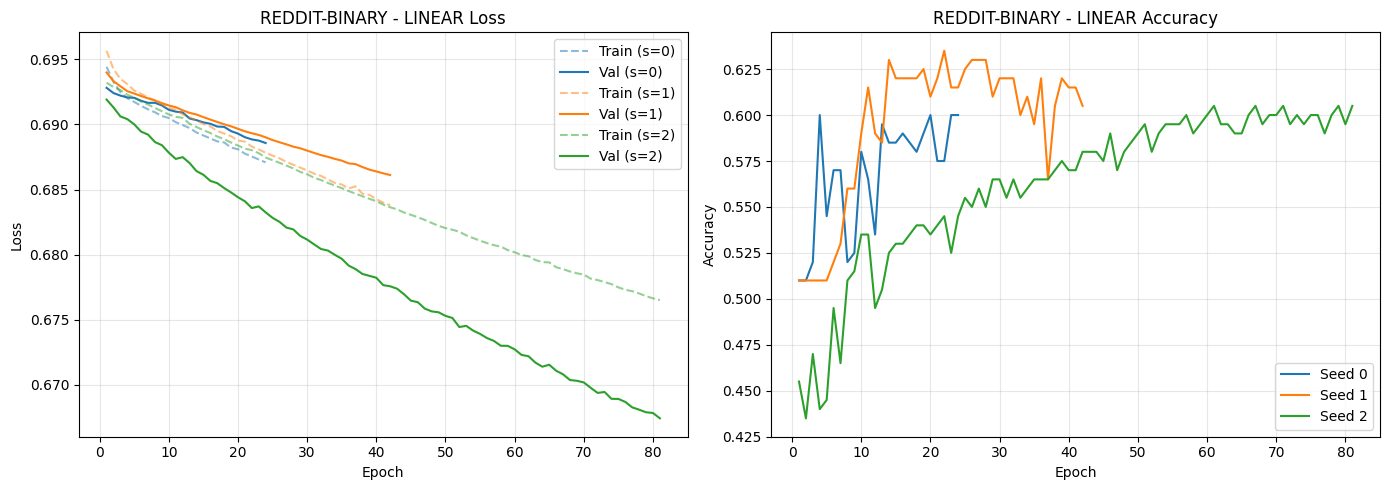


  Dataset: REDDIT-BINARY | Model: MLP | Pool: mean
  Hidden: 64 | Layers: 4 | Dropout: 0.5
  LR: 0.001 | BS: 64 | Seeds: [0, 1, 2]

Dataset: REDDIT-BINARY
  Graphs: 2000 | Features: 101 | Classes: 2
  Train/Val/Test: 1600/200/200
  Avg nodes: 429.6 ± 554.1
  Avg edges: 995.5 ± 1246.0

  Model: MLP | Params: 15,362 | Seed: 0 | Device: cuda
  Epoch   1 | tr_loss 0.7445 | val_loss 0.6998 | val_accuracy 0.5100 | 14.2s
  Epoch  10 | tr_loss 0.6181 | val_loss 0.5958 | val_accuracy 0.7050 | 142.9s
  Epoch  20 | tr_loss 0.5272 | val_loss 0.5807 | val_accuracy 0.7250 | 285.0s
  Epoch  30 | tr_loss 0.4654 | val_loss 0.5228 | val_accuracy 0.8000 | 428.1s
  Epoch  40 | tr_loss 0.4512 | val_loss 0.5425 | val_accuracy 0.7350 | 570.7s
  Early stop at epoch 46.
  Best val Accuracy: 0.8050 (epoch 26)
  Test Accuracy: 0.7800

  Model: MLP | Params: 15,362 | Seed: 1 | Device: cuda
  Epoch   1 | tr_loss 0.7287 | val_loss 0.6979 | val_accuracy 0.4900 | 13.9s
  Epoch  10 | tr_loss 0.5982 | val_loss 0.5590 

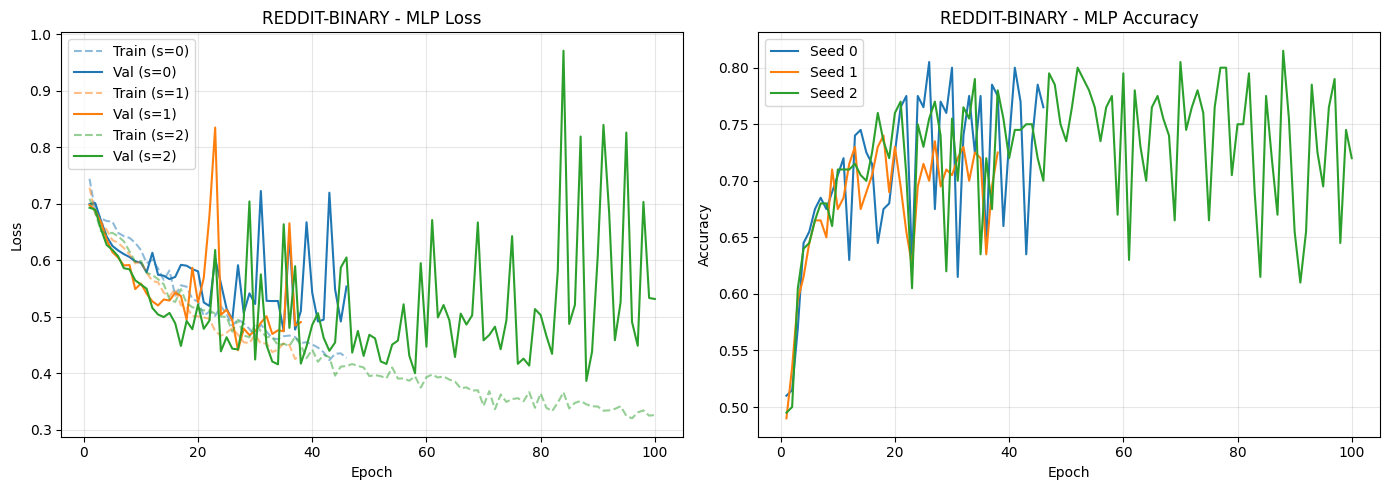


  Dataset: REDDIT-BINARY | Model: DEEPSETS | Pool: mean
  Hidden: 64 | Layers: 4 | Dropout: 0.5
  LR: 0.001 | BS: 64 | Seeds: [0, 1, 2]

Dataset: REDDIT-BINARY
  Graphs: 2000 | Features: 101 | Classes: 2
  Train/Val/Test: 1600/200/200
  Avg nodes: 429.6 ± 554.1
  Avg edges: 995.5 ± 1246.0

  Model: DEEPSETS | Params: 15,362 | Seed: 0 | Device: cuda
  Epoch   1 | tr_loss 0.6785 | val_loss 0.7309 | val_accuracy 0.4900 | 14.9s


KeyboardInterrupt: 

In [10]:
# Part 1: Evaluate Feature-Only models on PROTEINS and REDDIT-BINARY
part1_results = []

for dataset_name in ['PROTEINS', 'REDDIT-BINARY']:
    for model_name in ['linear', 'mlp', 'deepsets']:
        result = run_experiment(
            dataset_name=dataset_name,
            model_name=model_name,
            pool='mean',
            hidden=64,
            layers=4,
            dropout=0.5,
            lr=0.001,
            batch_size=64,
            epochs=100,
            patience=20,
            seeds=[0, 1, 2],
            save_plots=True
        )
        part1_results.append(result)

In [ ]:
# Part 1 Summary Table
print('\n' + '='*70)
print('Part 1 Results: Feature-Only Models')
print('='*70)
df1 = pd.DataFrame([{
    'Dataset': r['dataset'],
    'Model': r['model'].upper(),
    'Params': f"{r['params']:,}",
    'Val': f"{r['val_mean']:.4f} ± {r['val_std']:.4f}",
    'Test': f"{r['test_mean']:.4f} ± {r['test_std']:.4f}",
} for r in part1_results])
print(df1.to_string(index=False))

## 8. Part 2: All Models on All Datasets

In [ ]:
# Part 2: All models on all datasets
all_results = []

DATASETS = ['PROTEINS', 'IMDB-MULTI', 'REDDIT-BINARY', 'ogbg-molhiv']
ALL_MODELS = ['linear', 'mlp', 'deepsets', 'gcn', 'graphsage', 'gat', 'gin']

for dataset_name in DATASETS:
    for model_name in ALL_MODELS:
        result = run_experiment(
            dataset_name=dataset_name,
            model_name=model_name,
            pool='mean',
            hidden=64,
            layers=4,
            dropout=0.5,
            lr=0.001,
            batch_size=64,
            epochs=100,
            patience=20,
            seeds=[0, 1, 2],
            save_plots=True
        )
        all_results.append(result)

In [ ]:
# Part 2 Summary Table
print('\n' + '='*80)
print('Part 2 Results: All Models on All Datasets')
print('='*80)

df2 = pd.DataFrame([{
    'Dataset': r['dataset'],
    'Model': r['model'].upper(),
    'Type': 'Feature-Only' if r['model'] in ['linear','mlp','deepsets'] else 'Msg Passing',
    'Params': f"{r['params']:,}",
    'Metric': r['metric'],
    'Val': f"{r['val_mean']:.4f} ± {r['val_std']:.4f}",
    'Test': f"{r['test_mean']:.4f} ± {r['test_std']:.4f}",
} for r in all_results])
print(df2.to_string(index=False))

In [ ]:
# Create a nice comparison plot
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for i, dataset_name in enumerate(DATASETS):
    ds_results = [r for r in all_results if r['dataset'] == dataset_name]
    models = [r['model'].upper() for r in ds_results]
    means = [r['test_mean'] for r in ds_results]
    stds = [r['test_std'] for r in ds_results]
    colors = ['#ff6b6b' if r['model'] in ['linear','mlp','deepsets'] else '#4ecdc4' for r in ds_results]

    axes[i].barh(models, means, xerr=stds, color=colors, edgecolor='white', height=0.6, capsize=4)
    m_name = 'ROC-AUC' if ds_results[0]['metric'] == 'rocauc' else 'Accuracy'
    axes[i].set_xlabel(m_name)
    axes[i].set_title(dataset_name, fontsize=14, fontweight='bold')
    axes[i].grid(axis='x', alpha=0.3)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#ff6b6b', label='Feature-Only'),
                   Patch(facecolor='#4ecdc4', label='Message Passing')]
fig.legend(handles=legend_elements, loc='upper center', ncol=2, fontsize=12,
           bbox_to_anchor=(0.5, 1.05))
plt.tight_layout()
plt.savefig('results_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Save all results to CSV
df2.to_csv('experiment_results.csv', index=False)
print('Results saved to experiment_results.csv')

# Save as JSON too
import json
with open('experiment_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)
print('Results saved to experiment_results.json')

## 9. Model Complexity Analysis

In [ ]:
# Parameter count comparison
print('\nModel Parameter Counts (PROTEINS dataset):')
print('-' * 40)
dataset, nf, nc, _, _ = get_dataset('PROTEINS')
for name in ALL_MODELS:
    m = get_model(name, num_features=nf, num_classes=nc, hidden_dim=64, num_layers=4, dropout=0.5, pool='mean')
    print(f'  {name.upper():12s}: {count_parameters(m):>8,} params')

## 10. Discussion

### Key Observations

Add your analysis here after running the experiments:

1. **When does structural inductive bias help?**
   - Compare Feature-Only vs Message Passing results across datasets
   - Consider which datasets have meaningful edge semantics

2. **Dataset characteristics**
   - PROTEINS: Biological networks with rich node features
   - IMDB-MULTI: Social networks without node features
   - REDDIT-BINARY: Social networks without node features
   - ogbg-molhiv: Molecular graphs with rich node/edge features

3. **Overfitting and generalization**
   - Analyze training curves for signs of overfitting
   - Compare model complexity (parameter count) vs performance

4. **Model comparison insights**
   - GCN vs GraphSAGE vs GAT vs GIN: which performs best and why?
   - DeepSets vs GNNs: how much does message passing add?